# Tensor Product Smooths for 2D Surfaces

Model smooth interactions using tensor products.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.smoothing.splines.cubic import CubicSplineBasis
from aurora.smoothing.tensor import fit_tensor_product
from aurora.smoothing.penalties.difference import difference_penalty

# Generate data with 2D interaction
np.random.seed(42)
n = 200
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)
y = np.sin(x1) * np.cos(x2) + np.random.randn(n) * 0.3

# Create marginal cubic spline bases
knots1 = np.linspace(-2.5, 2.5, 8)  # Interior knots for x1
knots2 = np.linspace(-2.5, 2.5, 8)  # Interior knots for x2
basis1 = CubicSplineBasis(knots1)
basis2 = CubicSplineBasis(knots2)

# Create penalty matrices (2nd order difference penalties)
p1 = basis1.n_basis_
p2 = basis2.n_basis_
S1 = difference_penalty(p1, order=2)
S2 = difference_penalty(p2, order=2)

# Fit tensor product smooth
result = fit_tensor_product(
    x1, x2, y, 
    basis1, basis2, 
    S1, S2,
    lambda1=0.1,  # Smoothing in x1 direction
    lambda2=0.1   # Smoothing in x2 direction
)

print(f"Effective degrees of freedom: {result['edf']:.1f}")
print(f"Number of basis functions: {result['basis_matrix'].shape[1]}")
print(f"RMSE: {np.sqrt(np.mean((y - result['fitted_values'])**2)):.3f}")

Effective degrees of freedom: 46.2
Number of basis functions: 100
RMSE: 0.261


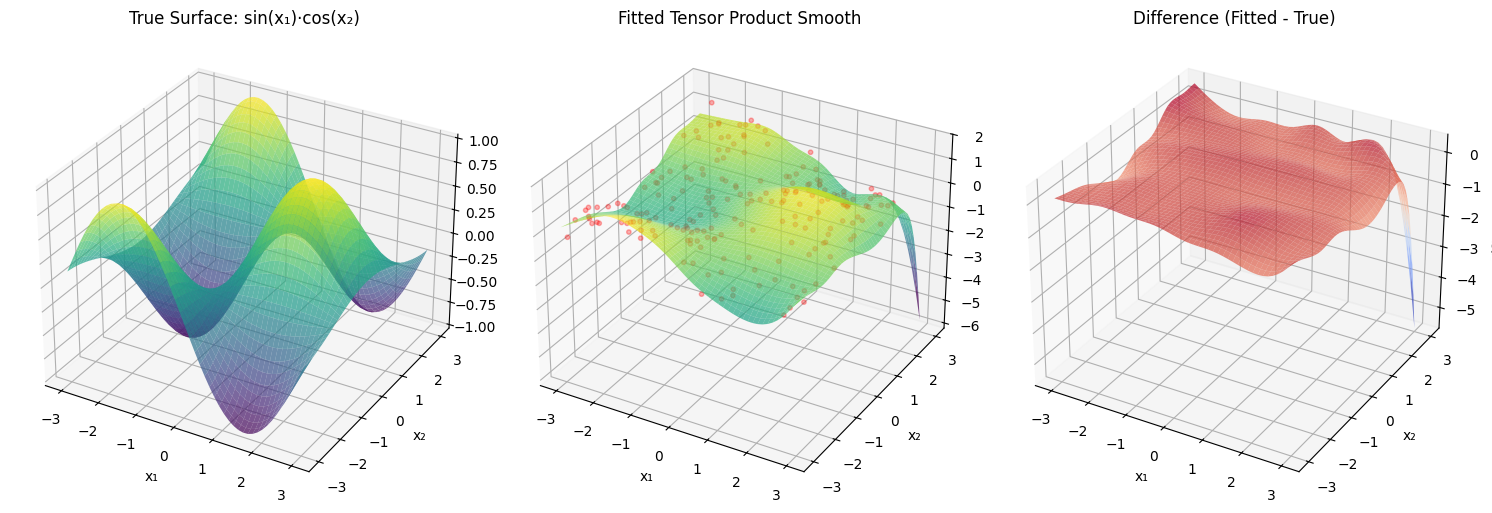

In [5]:
# Visualize the fitted surface
fig = plt.figure(figsize=(15, 5))

# Create grid for prediction
grid_size = 50
x1_grid = np.linspace(-3, 3, grid_size)
x2_grid = np.linspace(-3, 3, grid_size)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

# Compute tensor product basis for grid
from aurora.smoothing.tensor import tensor_product_basis
B_grid = tensor_product_basis(X1_grid.ravel(), X2_grid.ravel(), basis1, basis2)
y_grid = B_grid @ result['coefficients']
Y_grid = y_grid.reshape(grid_size, grid_size)

# True function
Y_true = np.sin(X1_grid) * np.cos(X2_grid)

# Plot 1: True surface
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1_grid, X2_grid, Y_true, cmap='viridis', alpha=0.7)
ax1.set_title('True Surface: sin(x₁)·cos(x₂)')
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_zlabel('y')

# Plot 2: Fitted surface
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X1_grid, X2_grid, Y_grid, cmap='viridis', alpha=0.7)
ax2.scatter(x1, x2, y, c='red', s=10, alpha=0.3, label='Data')
ax2.set_title('Fitted Tensor Product Smooth')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_zlabel('y')

# Plot 3: Residuals
ax3 = fig.add_subplot(133, projection='3d')
residuals_grid = Y_grid - Y_true
ax3.plot_surface(X1_grid, X2_grid, residuals_grid, cmap='coolwarm', alpha=0.7)
ax3.set_title('Difference (Fitted - True)')
ax3.set_xlabel('x₁')
ax3.set_ylabel('x₂')
ax3.set_zlabel('Difference')

plt.tight_layout()
plt.show()

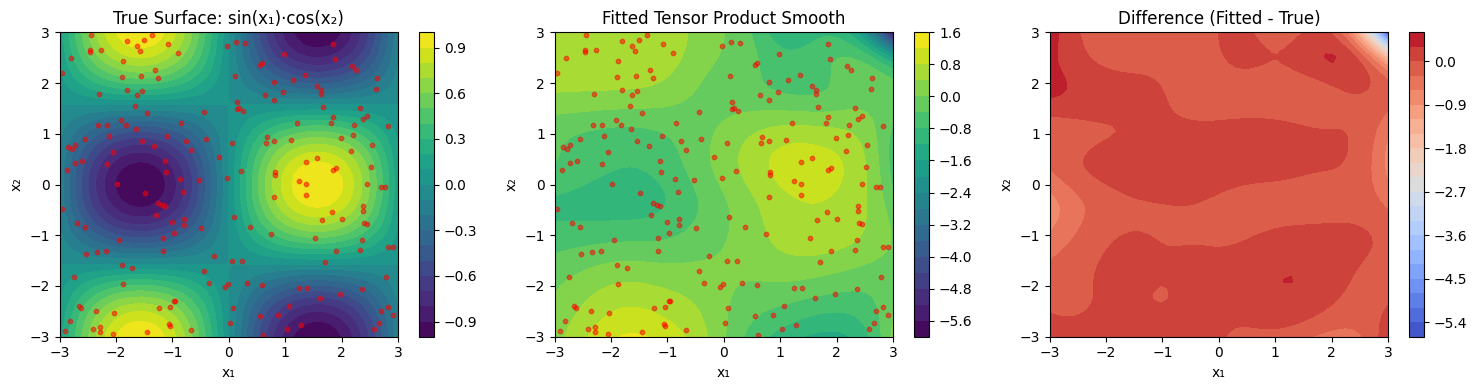


Max absolute difference: 5.560
Mean absolute difference: 0.137


In [7]:
# Contour plots for easier comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# True function contours
im1 = axes[0].contourf(X1_grid, X2_grid, Y_true, levels=20, cmap='viridis')
axes[0].scatter(x1, x2, c='red', s=10, alpha=0.5)
axes[0].set_title('True Surface: sin(x₁)·cos(x₂)')
axes[0].set_xlabel('x₁')
axes[0].set_ylabel('x₂')
plt.colorbar(im1, ax=axes[0])

# Fitted function contours
im2 = axes[1].contourf(X1_grid, X2_grid, Y_grid, levels=20, cmap='viridis')
axes[1].scatter(x1, x2, c='red', s=10, alpha=0.5)
axes[1].set_title('Fitted Tensor Product Smooth')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
plt.colorbar(im2, ax=axes[1])

# Difference contours
im3 = axes[2].contourf(X1_grid, X2_grid, residuals_grid, levels=20, cmap='coolwarm')
axes[2].set_title('Difference (Fitted - True)')
axes[2].set_xlabel('x₁')
axes[2].set_ylabel('x₂')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"\nMax absolute difference: {np.max(np.abs(residuals_grid)):.3f}")
print(f"Mean absolute difference: {np.mean(np.abs(residuals_grid)):.3f}")

## Understanding Tensor Product Smooths

### Key Concepts:
- **Tensor Product Basis**: Combines two marginal bases (one for each variable) using their outer product
- **Separate Penalties**: λ₁ controls smoothness in x₁ direction, λ₂ in x₂ direction
- **Effective Degrees of Freedom (EDF)**: Measures model complexity (lower = smoother)

### Smoothing Parameters:
- **Lower λ** (e.g., 0.01): More flexible, can overfit, higher EDF
- **Higher λ** (e.g., 10): Smoother, may underfit, lower EDF

Let's compare different smoothing levels:

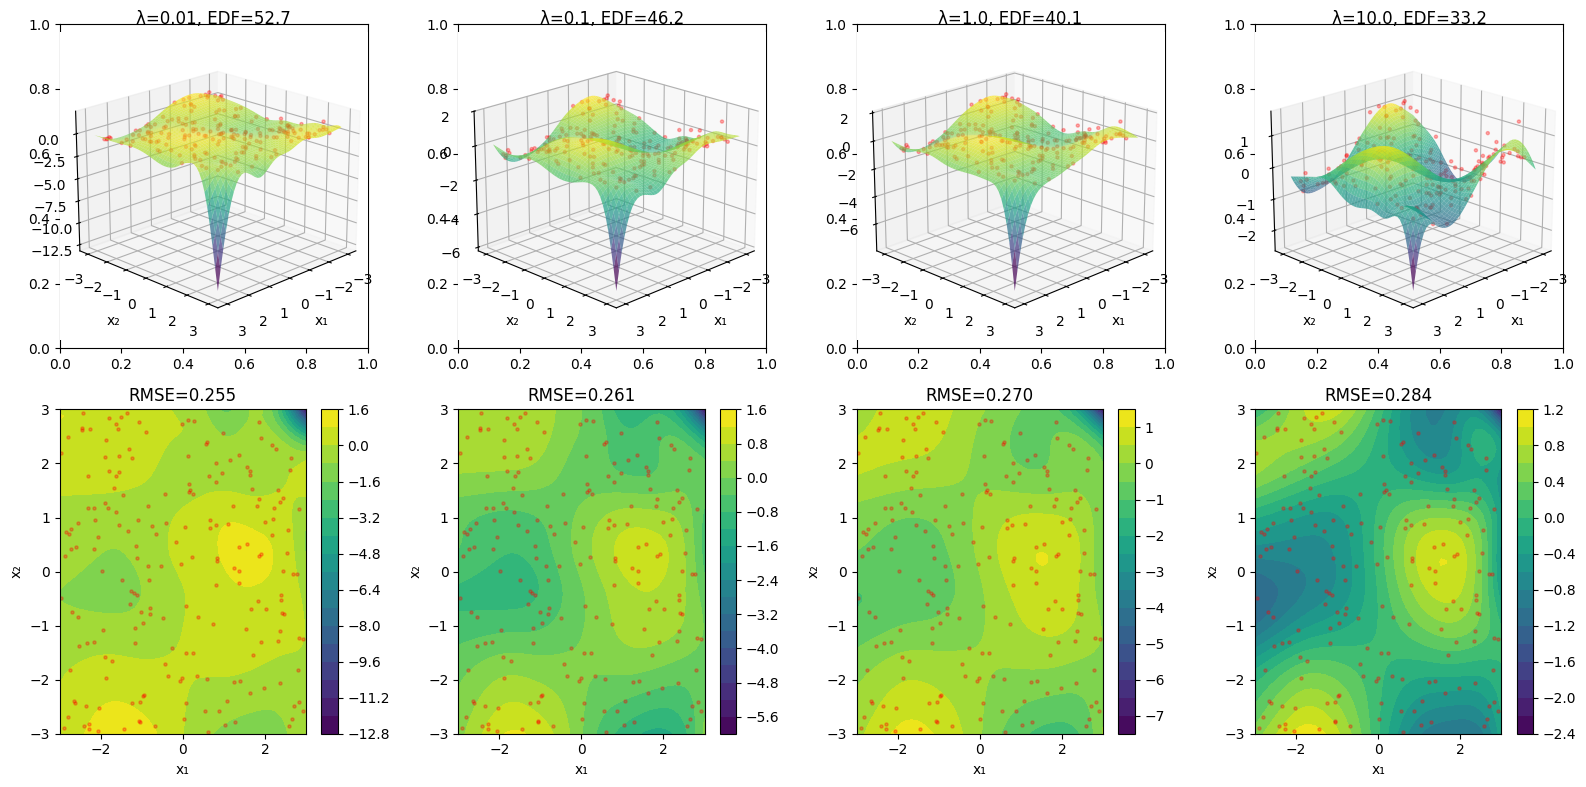


Summary:
λ       EDF     RMSE
-------------------------
  0.01    52.7   0.255
  0.10    46.2   0.261
  1.00    40.1   0.270
 10.00    33.2   0.284
  1.00    40.1   0.270
 10.00    33.2   0.284


In [8]:
# Compare different smoothing levels
lambdas = [0.01, 0.1, 1.0, 10.0]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, lam in enumerate(lambdas):
    # Fit with this lambda
    result_lam = fit_tensor_product(
        x1, x2, y, 
        basis1, basis2, 
        S1, S2,
        lambda1=lam,
        lambda2=lam
    )
    
    # Predict on grid
    B_grid = tensor_product_basis(X1_grid.ravel(), X2_grid.ravel(), basis1, basis2)
    y_grid_lam = B_grid @ result_lam['coefficients']
    Y_grid_lam = y_grid_lam.reshape(grid_size, grid_size)
    
    # 3D plot
    ax_3d = fig.add_subplot(2, 4, idx + 1, projection='3d')
    ax_3d.plot_surface(X1_grid, X2_grid, Y_grid_lam, cmap='viridis', alpha=0.7)
    ax_3d.scatter(x1, x2, y, c='red', s=5, alpha=0.3)
    ax_3d.set_title(f'λ={lam}, EDF={result_lam["edf"]:.1f}')
    ax_3d.set_xlabel('x₁')
    ax_3d.set_ylabel('x₂')
    ax_3d.view_init(elev=20, azim=45)
    
    # Contour plot
    ax_contour = axes[1, idx]
    im = ax_contour.contourf(X1_grid, X2_grid, Y_grid_lam, levels=20, cmap='viridis')
    ax_contour.scatter(x1, x2, c='red', s=5, alpha=0.3)
    ax_contour.set_title(f'RMSE={np.sqrt(np.mean((y - result_lam["fitted_values"])**2)):.3f}')
    ax_contour.set_xlabel('x₁')
    ax_contour.set_ylabel('x₂')
    plt.colorbar(im, ax=ax_contour)

plt.tight_layout()
plt.show()

print("\nSummary:")
print("λ       EDF     RMSE")
print("-" * 25)
for lam in lambdas:
    result_lam = fit_tensor_product(x1, x2, y, basis1, basis2, S1, S2, lambda1=lam, lambda2=lam)
    rmse = np.sqrt(np.mean((y - result_lam['fitted_values'])**2))
    print(f"{lam:6.2f}  {result_lam['edf']:6.1f}  {rmse:6.3f}")